# Occupancy detection (binary classification)

In [ ]:
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

## Load data

In [23]:
occupancy_detection = fetch_ucirepo(id=357) 
  
X = occupancy_detection.data.features 
y = occupancy_detection.data.targets 
  
print(occupancy_detection.metadata) 
print(occupancy_detection.variables) 

{'uci_id': 357, 'name': 'Occupancy Detection ', 'repository_url': 'https://archive.ics.uci.edu/dataset/357/occupancy+detection', 'data_url': 'https://archive.ics.uci.edu/static/public/357/data.csv', 'abstract': 'Experimental data used for binary classification (room occupancy) from Temperature,Humidity,Light and CO2. Ground-truth occupancy was obtained from time stamped pictures that were taken every minute.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate', 'Time-Series'], 'num_instances': 20560, 'num_features': 6, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Occupancy'], 'index_col': ['id'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2016, 'last_updated': 'Sat Apr 13 2024', 'dataset_doi': '10.24432/C5X01N', 'creators': ['Luis Candanedo'], 'intro_paper': {'ID': 470, 'type': 'NATIVE', 'title': 'Accurate occupancy detection of an office room from light, temperature, humidity and CO2

## Data analysis

In [24]:
X.head()

,date,Temperature,Humidity,Light,CO2,HumidityRatio
0,2015-02-04 17:51:00,23.18,27.272,426,721.25,0.00479298817650529
1,2015-02-04 17:51:59,23.15,27.2675,429.5,714,0.00478344094931065
2,2015-02-04 17:53:00,23.15,27.245,426,713.5,0.00477946352442199
3,2015-02-04 17:54:00,23.15,27.2,426,708.25,0.00477150882608175
4,2015-02-04 17:55:00,23.1,27.2,426,704.5,0.00475699293331518


In [25]:
X.describe()
    

,date,Temperature,Humidity,Light,CO2,HumidityRatio
count,20562,20562,20562,20562,20562,20562
unique,20561,486,2481,1906,5168,9690
top,Temperature,20.39,30.39,0,439,0.00484624668845129
freq,2,1050,267,12772,139,87


In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20562 entries, 0 to 20561
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           20562 non-null  object
 1   Temperature    20562 non-null  object
 2   Humidity       20562 non-null  object
 3   Light          20562 non-null  object
 4   CO2            20562 non-null  object
 5   HumidityRatio  20562 non-null  object
dtypes: object(6)
memory usage: 964.0+ KB


In [27]:
X = X.drop(['date'], axis=1)


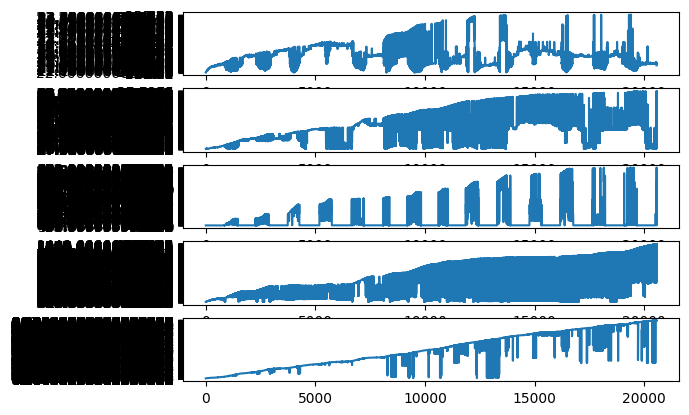

In [8]:
n_features = X.shape[1]
plt.figure()
for i in range(n_features):
    plt.subplot(n_features, 1, i+1)
    data = X.iloc[:, i]
    plt.plot(data.index, data.values)

In [28]:
y.describe()

,Occupancy
count,20560.000000
mean,0.231031
std,0.421503
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [29]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20562 entries, 0 to 20561
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Occupancy  20560 non-null  float64
dtypes: float64(1)
memory usage: 160.8 KB


In [34]:
mask = y.notna().squeeze()
X_clean = X[mask]
y_clean = y[mask]

In [35]:
X_clean.shape, y_clean.shape

((20560, 5), (20560, 1))

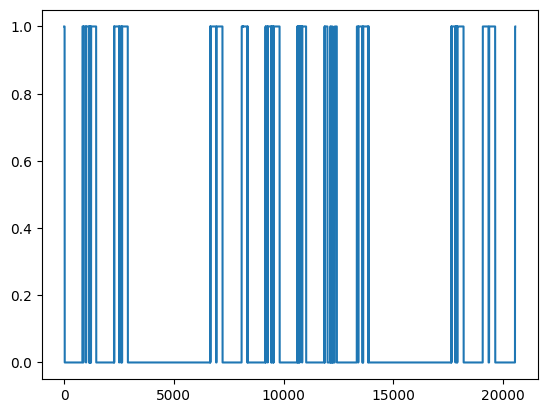

In [10]:
plt.plot(y)

In [36]:
y.value_counts()

Occupancy
0.0          15810
1.0           4750
Name: count, dtype: int64

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.1, stratify=y_clean)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train)

## Model Selection

In [41]:
def baseline_result(clf):
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    val_acc = accuracy_score(y_val, clf.predict(X_val))
    print(f'Train accuracy: {train_acc:.2f}, val accuracy: {val_acc:.2f}')

In [42]:
baseline_result(DummyClassifier())

Train accuracy: 0.77, val accuracy: 0.77


In [43]:
baseline_result(LogisticRegression())

Train accuracy: 0.99, val accuracy: 0.99


d:\python_envs\datascience_env\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [44]:
baseline_result(KNeighborsClassifier())

Train accuracy: 0.99, val accuracy: 0.99


d:\python_envs\datascience_env\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [45]:
baseline_result(SVC())

d:\python_envs\datascience_env\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Train accuracy: 0.99, val accuracy: 0.99


In [46]:
baseline_result(RandomForestClassifier())

d:\python_envs\datascience_env\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Train accuracy: 1.00, val accuracy: 0.99


## Results

| Model | Train accuracy | Val accuracy |
|-|-|-|
| Dummy | 0.77 | 0.77 |
| Logistic regression | 0.99 | 0.99 |
| K-NN | 0.99 | 0.99 |
| SVC | 0.99 | 0.99 |
| Random forest | 1 | 0.99 |


## Test results

In [48]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc:.2f}')

d:\python_envs\datascience_env\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Test accuracy: 0.99


In [51]:
print('Feature importance')
for i in range(n_features):
    name = X.columns[i]
    importance = clf.feature_importances_[i]
    print(name, importance)

Feature importance
Temperature 0.1910317918962762
Humidity 0.017345334679685732
Light 0.6688434651526106
CO2 0.09488764131505509
HumidityRatio 0.027891766956372317
